# DFT

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

`I have to hard code FILE_NAME, If you have better suggestion, please tell me.`

gmail address: arvin4943@gmail.com

In [4]:
working_dir = os.getcwd()
FOLDE_NAME = os.path.basename(working_dir)
FILE_NAME = 'fan_v1'

STOCK = 'BTC'
FREQ = '1h'

TRADE_PRICE = 'close'


SEQ_LENGTH = 120
BATCH_SIZE = 16

TRAIN_SPLIT = 0.6
VAL_SPLIT = 0.1
TEST_SPLIT = 1 - (TRAIN_SPLIT+VAL_SPLIT)

In [5]:
os.chdir(os.path.join('..','data'))
df = pd.read_csv('BTCUSD_2023_2024.csv', index_col='Gmt time')
df.index = pd.to_datetime(df.index, format="%d.%m.%Y %H:%M:%S.%f", errors='coerce')
df = df.rename(columns={'Date':'time', 'Open': 'open', 'High': 'high', 'Low': 'low', 'Close':'close', 'Volume':'volume'})

In [6]:
os.chdir('..')
from utils.utils import CreateTimeFrames
df = CreateTimeFrames(df, [FREQ])[FREQ]
df = df.iloc[-4050:,:]

In [7]:
close = df[f'{TRADE_PRICE}'].to_numpy(dtype=np.int32)
print(f'There are {close.size} {TRADE_PRICE} prices.')

There are 4050 close prices.


In [8]:
train = close[:int(np.floor(TRAIN_SPLIT*len(close)))]
val = close[int(np.ceil(TRAIN_SPLIT*len(close))): int(np.floor( (TRAIN_SPLIT+VAL_SPLIT)*len(close) ))]
test = close[int(np.ceil((TRAIN_SPLIT+VAL_SPLIT)*len(close))):]
assert len(train) + len(val) + len(test) == len(df), f"The dimension of price is dividable to SPLIT numbers. Splited len is:{len(train)+len(val)+len(test)} but df len is:{len(df)} "
print(f'train size:{train.size}, val size:{val.size}, test size:{test.size}.')


train size:2430, val size:405, test size:1215.


In [9]:
import torch

In [17]:
def create_sequence(data, seq_length=SEQ_LENGTH):

    num_seq = len(data) - seq_length

    xs = np.zeros((num_seq,seq_length), dtype=np.int32)
    ys = np.zeros(num_seq, dtype=np.int32)

    for i in range(0,num_seq):
        xs[i,:] = data[i:seq_length+i]
        ys[i] = data[i+seq_length]

    xs = torch.from_numpy(xs).unsqueeze(2)
    ys = torch.from_numpy(ys).unsqueeze(1)

    return xs, ys

xs, ys = create_sequence(train)

In [40]:
xs[0,:].shape

(120,)

np.fft.fftfreq(signal_length, sample_space )

signal_length: the number of samples in your dataset = 120

sample_space: because the distance between data points are the same we consider 1.

In [19]:
x = xs[:16,:,:]

In [48]:
def main_freq_part(x, k):
    freq_domain = torch.fft.rfft(x, dim=1)
    magnitudes = torch.abs(freq_domain)
    topk_indices = torch.topk(magnitudes, k , dim=1, largest=True).indices

    mask = torch.ones_like(freq_domain, dtype=torch.complex64)
    for b in range(x.shape[0]):
        mask[b, topk_indices[b], :] = 0

    filtered_freq = freq_domain * mask

    x_res = torch.fft.irfft(filtered_freq, dim=1)
    x_non = x - x_res

    return x_res, x_non

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


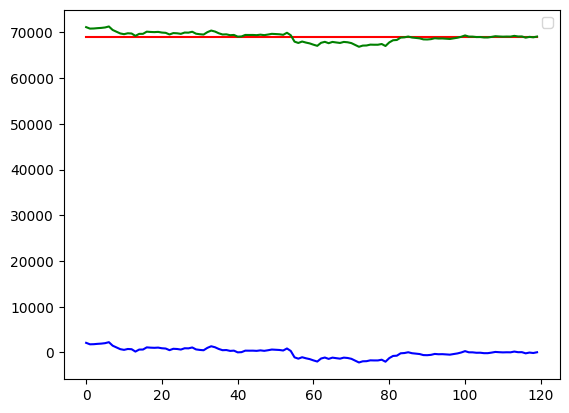

In [49]:
x_res, x_non = main_freq_part(x, 1)
plt.plot(x_res[0,:,:], color='blue')
plt.plot(x_non[0,:,:], color = 'red')
plt.plot(x[0,:,:], color='green')
plt.legend()
plt.show()

In [50]:
import torch.nn as nn

class MLPfreq(nn.Module):
    def __init__(self, seq_len, pred_len, enc_in):
        super(MLPfreq, self).__init__()
        self.seq_len = seq_len
        self.pred_len = pred_len
        self.channels = enc_in
        
        self.model_freq = nn.Sequential(
            nn.Linear(self.seq_len, 64),
            nn.ReLU(),
        )
        
        self.model_all = nn.Sequential(
            nn.Linear(64 + seq_len, 128),
            nn.ReLU(),
            nn.Linear(128, pred_len)
        )


    def forward(self, main_freq, x):
        inp = torch.concat([self.model_freq(main_freq), x], dim=-1)
        return self.model_all(inp)

In [51]:
class FAN(nn.Module):
    def __init__(self, seq_len = SEQ_LENGTH, pred_len = SEQ_LENGTH, enc_in = 1, freq_topk=10):
        super(FAN, self).__init__()

        self.seq_len = seq_len
        self.pred_len = pred_len
        self.enc_in = enc_in
        self.freq_topk = freq_topk
        self._build_model()
        self.pred_main_freq_signal = None
        self.pred_residual = None

    def _build_model(self):
        self.model_freq = MLPfreq(seq_len=self.seq_len, pred_len = self.pred_len, enc_in = self.enc_in)

    def loss(self, true):
        residual, pred_main = main_freq_part(true, self.freq_topk)
        lf = nn.functional.mse_loss
        return lf(self.pred_main_freq_signal, pred_main) + lf(self.pred_residual, residual)
    
    def normalize(self, input):
        x_non, x_res = main_freq_part(input, self.freq_topk)
        self.pred_main_freq_signal = self.model_freq(x_res.transpose(1,2), input.transpose(1,2)).transpose(1,2)
        return x_non.reshape(input.shape[0],input.shape[1],input.shape[2])
    
    def denormalize(self, x_non):
        self.pred_residual = x_non
        output = self.pred_residual + self.pred_main_freq_signal
        return output.reshape(x_non.shape[0], x_non.shape[1], x_non.shape[2])
        

    def forward(self, batch_x, mode='n'):
        if mode == 'n':
            return self.normalize(batch_x)
        elif mode == 'd':
            return self.denormalize(batch_x)
        else:
            raise ValueError("Mode must be 'n' or 'd'.")



#### Normalize with FAN

In [52]:
fan_layer = FAN()
x_normalized = fan_layer(x,mode='n')
print(f"Normalized Output Shape: {x_normalized.shape}")

x_reconstructed = fan_layer(x_normalized, mode='d')
print(f"Reconstructed Output Shape: {x_reconstructed.shape}")



Normalized Output Shape: torch.Size([16, 120, 1])
Reconstructed Output Shape: torch.Size([16, 120, 1])


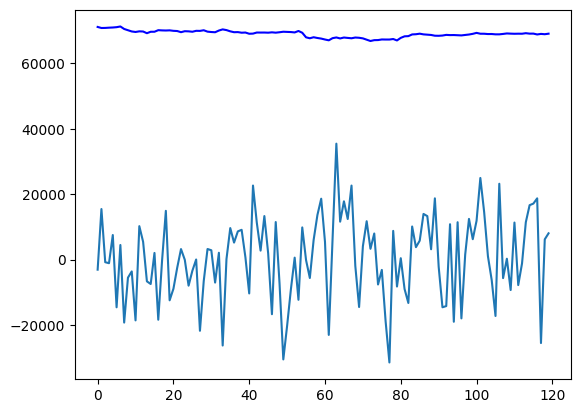

In [57]:
plt.plot(x[0,:,:],color = 'blue')
plt.plot(x_reconstructed[0,:,:].detach().numpy())

In [38]:
x = xs[:16,:,:]

freq_domain = torch.fft.rfft(x)

magnitudes = torch.abs(freq_domain)
# print(f'the magnitudes shape is :{magnitudes.shape}')

topk_indices = torch.topk(magnitudes, 1, dim=1, largest=True).indices
# print(f'the topk_indices shape is :{topk_indices.shape}')

mask = torch.ones_like(freq_domain, dtype=torch.bool)
# print(f'the mask shape is :{mask.shape}')


for b in range(x.shape[0]):
    mask[b, topk_indices[b], :] = False

filtered_freq = freq_domain * mask
# print(f'the filtered_freq shape is :{filtered_freq.shape}')

stationary_signal = torch.fft.irfft(filtered_freq, SEQ_LENGTH, dim=1)
# print(f'the stationary_signal shape is"{stationary_signal.shape}')

from statsmodels.tsa.stattools import adfuller
p_value_mat = np.zeros((x.shape[0], 2), dtype=np.float32)
for i in range(0,x.shape[0]):
   p_value_mat[i,0] = adfuller(xs[i,:,:])[1]
   p_value_mat[i,1] = adfuller(stationary_signal[i,:,:])[1]
print(f'The stationarity index before and after normalization are: {np.mean(p_value_mat, axis=0)}.')

The stationarity index before and after normalization are: [0.23425399 0.06718899].


#### Denormalization FAN

In [218]:
x_res = stationary_signal
x_non = x - x_res
x_res




tensor([[[ 6.8505e+04],
         [-7.3776e+02],
         [-1.0210e+03],
         ...,
         [-4.9010e+02],
         [-1.0210e+03],
         [-7.3776e+02]],

        [[ 6.8442e+04],
         [-7.3459e+02],
         [-1.1312e+03],
         ...,
         [-6.1950e+02],
         [-1.1312e+03],
         [-7.3459e+02]],

        [[ 6.8384e+04],
         [-7.3038e+02],
         [-1.2230e+03],
         ...,
         [-7.3464e+02],
         [-1.2230e+03],
         [-7.3038e+02]],

        ...,

        [[ 6.7898e+04],
         [ 1.3264e+01],
         [ 3.4439e+02],
         ...,
         [ 1.2329e+03],
         [ 3.4439e+02],
         [ 1.3264e+01]],

        [[ 6.7859e+04],
         [-8.9769e+00],
         [ 2.4848e+02],
         ...,
         [ 1.2124e+03],
         [ 2.4848e+02],
         [-8.9768e+00]],

        [[ 6.7819e+04],
         [-3.6685e+01],
         [ 1.4787e+02],
         ...,
         [ 1.1566e+03],
         [ 1.4787e+02],
         [-3.6685e+01]]])